In [1]:
import sys
sys.path.append('../utils')
from utils_models import *
from scipy.optimize import minimize

In [113]:
EJ = 4
EC = 4/5.9
EL = 4/29.2
fluxonium1 = scqubits.Fluxonium(EJ=EJ,
                        EC=EC,
                        EL=EL,
                        flux=0,cutoff=110,
                        truncated_dim=20)
freq = {
    'g0g1':[],
    'e0e1':[],
    'f0f1':[],
    'g1g2':[],
    'e1e2':[],
    'f1f2':[],
    'g2g3':[],
    'e2e3':[],
    'f2f3':[]
}

me = {
    'g1g2':[],
    'e1e2':[],
    'f1f2':[]
}

tmon_freq = []

EJ_list = np.linspace(2,6,100)
for f_EJ in tqdm(EJ_list):


    fluxonium2 =  scqubits.Fluxonium(EJ=f_EJ,
                        EC=4/4,
                        EL=4/8,
                        flux=0.45,cutoff=110,
                        truncated_dim=20)

    system = FluxoniumFluxoniumSystem(
        fluxonium1  = fluxonium1,
        fluxonium2 = fluxonium2,
        computaional_states = '1,2',
        g_strength = 0.1,
        )

    def dressed_ener(ql,ol):
        return system.evals[system.product_to_dressed[(ql,ol)]]
    ols = system.fluxonium2.truncated_dim
    op = system.hilbertspace.op_in_dressed_eigenbasis(fluxonium2.n_operator)

    tmon_freq.append(fluxonium2.eigenvals()[1]-fluxonium2.eigenvals()[0])
    freq['g1g2'].append(dressed_ener(0,2)-dressed_ener(0,1))
    freq['e1e2'].append(dressed_ener(1,2)-dressed_ener(1,1))
    freq['f1f2'].append(dressed_ener(2,2)-dressed_ener(2,1))

    freq['g0g1'].append(dressed_ener(0,2)-dressed_ener(0,0))
    freq['e0e1'].append(dressed_ener(1,2)-dressed_ener(1,0))
    freq['f0f1'].append(dressed_ener(2,2)-dressed_ener(2,0))

    freq['g2g3'].append(dressed_ener(0,3)-dressed_ener(0,2))
    freq['e2e3'].append(dressed_ener(1,3)-dressed_ener(1,2))
    freq['f2f3'].append(dressed_ener(2,3)-dressed_ener(2,2))


    me['g1g2'].append(abs(op[system.product_to_dressed[(0,1)],  system.product_to_dressed[(0,2)]]))
    me['e1e2'].append(abs(op[system.product_to_dressed[(1,1)],  system.product_to_dressed[(1,2)]]))
    me['f1f2'].append(abs(op[system.product_to_dressed[(2,1)],  system.product_to_dressed[(2,2)]]))


100%|██████████| 100/100 [00:56<00:00,  1.79it/s]


In [60]:
EJ_list = np.linspace(2,6,100)

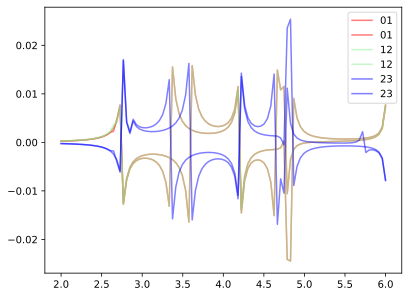

In [120]:
# plt.plot(np.array(tmon_freq),np.array(freq['g0g1'])-np.array(freq['e0e1']),label='g0')
# plt.plot(np.array(tmon_freq),np.array(freq['f0f1'])-np.array(freq['e0e1']),label='f0')

# plt.plot(np.array(tmon_freq),np.array(freq['g1g2'])-np.array(freq['e1e2']),label='g1')
# plt.plot(np.array(tmon_freq),np.array(freq['f1f2'])-np.array(freq['e1e2']),label='f1')


plt.plot(EJ_list,np.array(freq['g0g1'])-np.array(freq['e0e1']),label='01',color='red',alpha=0.5)
plt.plot(EJ_list,np.array(freq['f0f1'])-np.array(freq['e0e1']),label='01',color='red',alpha=0.5)

plt.plot(EJ_list,np.array(freq['g1g2'])-np.array(freq['e1e2']),label='12',color='lightgreen',alpha=0.5)
plt.plot(EJ_list,np.array(freq['f1f2'])-np.array(freq['e1e2']),label='12',color='lightgreen',alpha=0.5)

plt.plot(EJ_list,np.array(freq['g2g3'])-np.array(freq['e2e3']),label='23',color='blue',alpha=0.5)
plt.plot(EJ_list,np.array(freq['f2f3'])-np.array(freq['e2e3']),label='23',color='blue',alpha=0.5)

plt.legend()

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

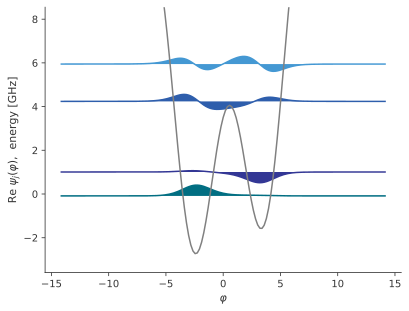

In [30]:
EJ = 4
EC = 4/5.9
EL = 4/29.2
fluxonium1 = scqubits.Fluxonium(EJ=EJ,
                        EC=EC,
                        EL=EL,
                        flux=0,cutoff=110,
                        truncated_dim=12)

fluxonium2 =  scqubits.Fluxonium(EJ=4,
                        EC=4/4,
                        EL=4/10,
                        flux=0.42,cutoff=110,
                        truncated_dim=12)

system = FluxoniumFluxoniumSystem(
    fluxonium1  = fluxonium1,
    fluxonium2 = fluxonium2,
    computaional_states = '1,2',
    g_strength = 0.01,
    )
fluxonium2.plot_wavefunction(which=[0,1,2,3])


In [31]:
system.evals[system.product_to_dressed[(0,3)]]-system.evals[system.product_to_dressed[(0,2)]], \
system.evals[system.product_to_dressed[(1,3)]]-system.evals[system.product_to_dressed[(1,2)]], \
system.evals[system.product_to_dressed[(2,3)]]-system.evals[system.product_to_dressed[(2,2)]]

(1.7081494055298272, 1.7081759253813837, 1.7081547124409049)

# Let's try EIT

In [36]:
initial_states = [
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(0,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(1,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(2,0)])
]

e_ops = []
for ql in range(3):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))

# Get the Raman pi pulse parameters
op = system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)
# Omega_p = 1/200
# Omega_c = Omega_p * 5
# Delta = 0.01
# length = 1/Omega_p

length = 210
tlist = np.linspace(0,length,int(length))
Delta = 0

# aera_probe = np.pi  * 0.2
# amplitude_g02 = aera_probe/( length * abs(op[system.product_to_dressed[(0,2)],  system.product_to_dressed[(0,0)]])   )
# amplitude_g21 = aera_probe/( length * abs(op[system.product_to_dressed[(0,2)],  system.product_to_dressed[(0,1)]])   )

# amplitude_e02 = aera_probe/( length * abs(op[system.product_to_dressed[(1,2)],  system.product_to_dressed[(1,0)]])   )
# amplitude_e21 = aera_probe/( length * abs(op[system.product_to_dressed[(1,2)],  system.product_to_dressed[(1,1)]])   )

# amplitude_f02 = aera_probe/( length * abs(op[system.product_to_dressed[(2,2)],  system.product_to_dressed[(2,0)]])   )
# amplitude_f21 = aera_probe/( length * abs(op[system.product_to_dressed[(2,2)],  system.product_to_dressed[(2,1)]])   )

# amplitude_g02, amplitude_g21,     amplitude_e02, amplitude_e21,     amplitude_f02, amplitude_f21

 Total run time:  16.11s*] Elapsed 16.11s / Remaining 00:00:00:00[          2%           ] Elapsed 0.17s / Remaining 00:00:00:08
 Total run time:  16.15s*] Elapsed 16.15s / Remaining 00:00:00:00
 Total run time:  16.16s*] Elapsed 16.16s / Remaining 00:00:00:00


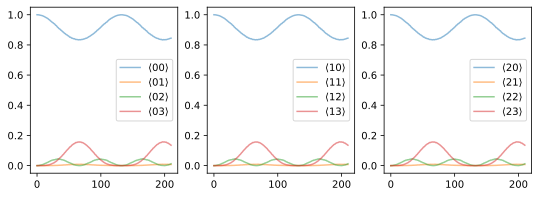

In [39]:
results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d':system.evals[system.product_to_dressed[(1,3)]]-system.evals[system.product_to_dressed[(1,2)]] - Delta/(2*np.pi),
                    'amp': 0.2/(2*np.pi),
                    't_rise':  1e-5,
                    't_square': 1000
                  },
                ),
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=second_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d1':system.evals[system.product_to_dressed[(2,2)]] - system.evals[system.product_to_dressed[(2,0)]] +Delta/(2*np.pi),
                    'amp1':0.007218540621271747,
                    't_rise1': 1e-5,
                    't_square1': 1000
                  },
                ),
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=third_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d2':system.evals[system.product_to_dressed[(2,2)]] - system.evals[system.product_to_dressed[(2,1)]] + Delta/(2*np.pi),
                    'amp2': 0.0101,
                    't_rise2': 1e-5,
                    't_square2': 1000
                  },
                )
            ],
        c_ops = None,
        e_ops = e_ops,
        post_processing = []
    )

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()

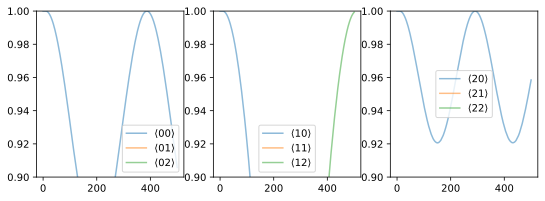

In [98]:
fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2)],
                                    [(1,0),(1,1),(1,2)],
                                    [(2,0),(2,1),(2,2)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*3+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()
    axes[i].set_ylim(1-1e-1,1)

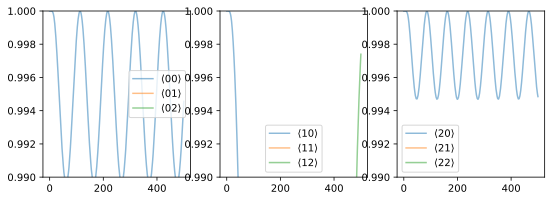

In [86]:

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2)],
                                    [(1,0),(1,1),(1,2)],
                                    [(2,0),(2,1),(2,2)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*3+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()
    axes[i].set_ylim(1-1e-2,1)

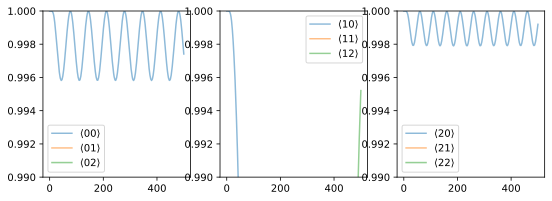

In [82]:

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2)],
                                    [(1,0),(1,1),(1,2)],
                                    [(2,0),(2,1),(2,2)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*3+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()
    axes[i].set_ylim(1-1e-2,1)

In [ ]:
system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)[system.product_to_dressed[(2,2)],system.product_to_dressed[(2,0)]], \
 system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)[system.product_to_dressed[(1,2)],system.product_to_dressed[(1,0)]], \
 system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)[system.product_to_dressed[(0,2)],system.product_to_dressed[(0,0)]],  \
system.evals[system.product_to_dressed[(2,2)]] - system.evals[system.product_to_dressed[(2,0)]],\
  system.evals[system.product_to_dressed[(1,2)]] - system.evals[system.product_to_dressed[(1,0)]],\
    system.evals[system.product_to_dressed[(0,2)]] - system.evals[system.product_to_dressed[(0,0)]]


(-0.3174102364760903j,
 -0.3174124356112899j,
 -0.3174261222262945j,
 3.6474585321024646,
 3.647493137017765,
 3.6474684524747047)